
EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM
1. Show all employees
2. Add new employee
3. Delete employee
4. Update employee score
5. Show top performer
6. Show lowest performer
7. Average performance score
8. Department-wise average
9. Employees above average
10. Employee performance chart
11. Department-wise average chart
12. Top 5 performers chart
13. Score distribution chart
14. Department comparison box plot
15. Exit


Enter your choice:  1


    emp_id      name department  score
0      101    Anurag         HR     15
1      102    Shivam         HR     15
2      103      Ajay    Finance     10
3      104       Ram    Finance     13
4      105     Rohit    Finance     15
5      110   Pratham    Finance     17
6      114     Sumit      Sales     12
7      115  Jitendra         IT     15
8      120    Gaurav      Sales     16
9      121     Megha         HR     18
10     123   Vidushi      Sales     14
11     125     Jyoti      Sales     16
12     150      Aman      Sales     15
13     155     Komal      Sales     14
14     171    Paarth         IT     17
15     177      Neha      Sales     10
16     180     Krish         HR     17
17     210      Raju         IT     16

EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM
1. Show all employees
2. Add new employee
3. Delete employee
4. Update employee score
5. Show top performer
6. Show lowest performer
7. Average performance score
8. Department-wise average
9. Employees above average
10.

Enter your choice:  5


   emp_id   name department  score
9     121  Megha         HR     18

EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM
1. Show all employees
2. Add new employee
3. Delete employee
4. Update employee score
5. Show top performer
6. Show lowest performer
7. Average performance score
8. Department-wise average
9. Employees above average
10. Employee performance chart
11. Department-wise average chart
12. Top 5 performers chart
13. Score distribution chart
14. Department comparison box plot
15. Exit


Enter your choice:  12


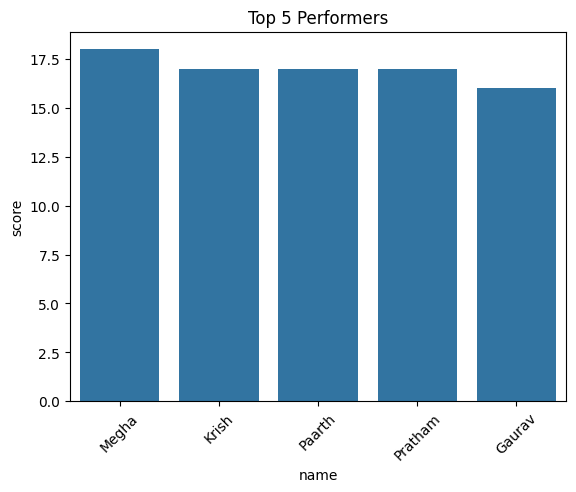


EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM
1. Show all employees
2. Add new employee
3. Delete employee
4. Update employee score
5. Show top performer
6. Show lowest performer
7. Average performance score
8. Department-wise average
9. Employees above average
10. Employee performance chart
11. Department-wise average chart
12. Top 5 performers chart
13. Score distribution chart
14. Department comparison box plot
15. Exit


Enter your choice:  6


    emp_id  name department  score
2      103  Ajay    Finance     10
15     177  Neha      Sales     10

EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM
1. Show all employees
2. Add new employee
3. Delete employee
4. Update employee score
5. Show top performer
6. Show lowest performer
7. Average performance score
8. Department-wise average
9. Employees above average
10. Employee performance chart
11. Department-wise average chart
12. Top 5 performers chart
13. Score distribution chart
14. Department comparison box plot
15. Exit


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def connect_db():
    conn = sqlite3.connect("employees.db")
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS employees (
            emp_id INTEGER PRIMARY KEY,
            name TEXT,
            department TEXT,
            score INTEGER
        )
    """)
    conn.commit()
    return conn, cursor

def load_data(cursor):
    cursor.execute("SELECT * FROM employees")
    data = cursor.fetchall()
    return pd.DataFrame(data, columns=["emp_id", "name", "department", "score"])

def add_employee(cursor, conn):
    try:
        emp_id = int(input("Enter Employee ID: "))
        name = input("Enter Name: ")
        dept = input("Enter Department: ")
        score = int(input("Enter Performance Score: "))
        cursor.execute(
            "INSERT INTO employees VALUES (?, ?, ?, ?)",
            (emp_id, name, dept, score)
        )
        conn.commit()
        print("Employee added successfully!")
    except:
        print("Invalid input!")

def delete_employee(cursor, conn):
    emp_id = int(input("Enter Employee ID to delete: "))
    cursor.execute("DELETE FROM employees WHERE emp_id=?", (emp_id,))
    conn.commit()
    print("Employee deleted successfully!")

def update_score(cursor, conn):
    emp_id = int(input("Enter Employee ID: "))
    new_score = int(input("Enter new score: "))
    cursor.execute(
        "UPDATE employees SET score=? WHERE emp_id=?",
        (new_score, emp_id)
    )
    conn.commit()
    print("Score updated successfully!")

def show_employees(df):
    print(df if not df.empty else "No records found!")

def top_performer(df):
    if df.empty:
        print("No data available!")
        return
    print(df[df["score"] == df["score"].max()])

def lowest_performer(df):
    if df.empty:
        print("No data available!")
        return
    print(df[df["score"] == df["score"].min()])

def average_score(df):
    if df.empty:
        print("No data available!")
    else:
        print(f"Average Performance Score: {df['score'].mean():.2f}")

def department_average(df):
    if df.empty:
        print("No data available!")
        return
    print(df.groupby("department")["score"].mean())

def above_average(df):
    if df.empty:
        print("No data available!")
        return
    avg = df["score"].mean()
    print(df[df["score"] > avg])

def employee_performance_chart(df):
    if df.empty:
        print("No data available!")
        return
    sns.barplot(x="name", y="score", data=df)
    plt.title("Employee Performance Scores")
    plt.xticks(rotation=45)
    plt.show()

def department_average_chart(df):
    if df.empty:
        print("No data available!")
        return
    dept_avg = df.groupby("department")["score"].mean().reset_index()
    sns.barplot(x="department", y="score", data=dept_avg)
    plt.title("Department-wise Average Performance")
    plt.show()

def top_five_chart(df):
    if df.empty:
        print("No data available!")
        return
    top5 = df.sort_values(by="score", ascending=False).head(5)
    sns.barplot(x="name", y="score", data=top5)
    plt.title("Top 5 Performers")
    plt.xticks(rotation=45)
    plt.show()

def score_distribution(df):
    if df.empty:
        print("No data available!")
        return
    plt.hist(df["score"], bins=10)
    plt.title("Performance Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Employees")
    plt.show()

def department_boxplot(df):
    if df.empty:
        print("No data available!")
        return
    sns.boxplot(x="department", y="score", data=df)
    plt.title("Department-wise Score Comparison")
    plt.show()

def main():
    conn, cursor = connect_db()

    while True:
        df = load_data(cursor)

        print("\n" + "="*60)
        print("EMPLOYEE PERFORMANCE MANAGEMENT SYSTEM")
        print("="*60)
        print("1. Show all employees")
        print("2. Add new employee")
        print("3. Delete employee")
        print("4. Update employee score")
        print("5. Show top performer")
        print("6. Show lowest performer")
        print("7. Average performance score")
        print("8. Department-wise average")
        print("9. Employees above average")
        print("10. Employee performance chart")
        print("11. Department-wise average chart")
        print("12. Top 5 performers chart")
        print("13. Score distribution chart")
        print("14. Department comparison box plot")
        print("15. Exit")

        try:
            choice = int(input("Enter your choice: "))

            if choice == 1:
                show_employees(df)
            elif choice == 2:
                add_employee(cursor, conn)
            elif choice == 3:
                delete_employee(cursor, conn)
            elif choice == 4:
                update_score(cursor, conn)
            elif choice == 5:
                top_performer(df)
            elif choice == 6:
                lowest_performer(df)
            elif choice == 7:
                average_score(df)
            elif choice == 8:
                department_average(df)
            elif choice == 9:
                above_average(df)
            elif choice == 10:
                employee_performance_chart(df)
            elif choice == 11:
                department_average_chart(df)
            elif choice == 12:
                top_five_chart(df)
            elif choice == 13:
                score_distribution(df)
            elif choice == 14:
                department_boxplot(df)
            elif choice == 15:
                print("Exiting program...")
                break
            else:
                print("Invalid choice!")

        except ValueError:
            print("Please enter a valid number!")

    conn.close()

if __name__ == "__main__":
    main()
